In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE

In [2]:
data = pd.read_csv("health_lifestyle_dataset.csv")

In [3]:
data

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,53,Male,33.1,4726,3.9,2.0,3118,0,1,56,105,76,282,0,0
99996,99997,22,Male,35.1,11554,4.5,3.1,1967,0,0,51,149,77,192,0,0
99997,99998,37,Male,18.9,3924,3.8,1.0,2328,0,0,69,92,117,218,0,0
99998,99999,72,Female,27.8,16110,5.6,0.8,3093,0,0,93,164,72,188,0,0


In [4]:
data.describe()

,id,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,48.525990,29.024790,10479.87029,6.491784,2.751496,2603.341200,0.200940,0.300020,74.457420,134.58063,89.508850,224.300630,0.299150,0.248210
std,28867.657797,17.886768,6.352666,5483.63236,2.021922,1.297338,807.288563,0.400705,0.458269,14.423715,25.95153,17.347041,43.327749,0.457888,0.431976
min,1.000000,18.000000,18.000000,1000.00000,3.000000,0.500000,1200.000000,0.000000,0.000000,50.000000,90.00000,60.000000,150.000000,0.000000,0.000000
25%,25000.750000,33.000000,23.500000,5729.00000,4.700000,1.600000,1906.000000,0.000000,0.000000,62.000000,112.00000,74.000000,187.000000,0.000000,0.000000
50%,50000.500000,48.000000,29.000000,10468.00000,6.500000,2.800000,2603.000000,0.000000,0.000000,74.000000,135.00000,89.000000,224.000000,0.000000,0.000000
75%,75000.250000,64.000000,34.500000,15229.00000,8.200000,3.900000,3299.000000,0.000000,1.000000,87.000000,157.00000,105.000000,262.000000,1.000000,0.000000
max,100000.000000,79.000000,40.000000,19999.00000,10.000000,5.000000,3999.000000,1.000000,1.000000,99.000000,179.00000,119.000000,299.000000,1.000000,1.000000


In [5]:
print(data.info())
print("Data shape: ", data.shape)
print("columns: ", data.columns)
print("Missing not available values: ", data.isna().sum())
print("Duplicated: ", data.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 100000 non-null  int64  
 1   age                100000 non-null  int64  
 2   gender             100000 non-null  object 
 3   bmi                100000 non-null  float64
 4   daily_steps        100000 non-null  int64  
 5   sleep_hours        100000 non-null  float64
 6   water_intake_l     100000 non-null  float64
 7   calories_consumed  100000 non-null  int64  
 8   smoker             100000 non-null  int64  
 9   alcohol            100000 non-null  int64  
 10  resting_hr         100000 non-null  int64  
 11  systolic_bp        100000 non-null  int64  
 12  diastolic_bp       100000 non-null  int64  
 13  cholesterol        100000 non-null  int64  
 14  family_history     100000 non-null  int64  
 15  disease_risk       100000 non-null  int64  
dtypes: 

## Dataset Observations

### General Information
- **Dataset Shape:** (100,000, 16)  
  → 100,000 rows and 16 columns
- **Memory Usage:** ~12.2 MB
- **Target Column:** `disease_risk` (binary: 0 or 1)
- **Feature Types:**  
  - Numerical: 15  
  - Categorical: 1

### Column Overview

#### Numerical Columns (15)
- `id`
- `age`
- `bmi`
- `daily_steps`
- `sleep_hours`
- `water_intake_l`
- `calories_consumed`
- `smoker`
- `alcohol`
- `resting_hr`
- `systolic_bp`
- `diastolic_bp`
- `cholesterol`
- `family_history`
- `disease_risk`

#### Categorical Columns (1)
- `gender`


In [6]:
print(data["disease_risk"].value_counts()[0] - [1])

[75178]


In [7]:
print(data["disease_risk"].value_counts()[0] - data["disease_risk"].value_counts()[1])

50358


In [8]:
counts = data["disease_risk"].value_counts()

# Percentage
print(data["disease_risk"].value_counts(normalize=True) * 100)

# Ratio
print(f"Ratio: {counts[0]/counts[1]:.2f} : 1")

disease_risk
0    75.179
1    24.821
Name: proportion, dtype: float64
Ratio: 3.03 : 1


## Class Imbalance Observation

### Why?
- A balanced dataset typically has classes close to a 50–50 split or at least within a similar range.
- In this dataset, **class 0 has approximately three times more samples than class 1**, indicating a clear class imbalance.

### Impact
- Models may become **biased toward predicting the majority class (0)**.
- Overall **accuracy may appear high**, but performance metrics for the **minority class (1)** especially **recall and precision** are likely to suffer.
- This makes metrics such as **F1-score, recall, precision, and ROC-AUC** more reliable than accuracy alone for evaluation.


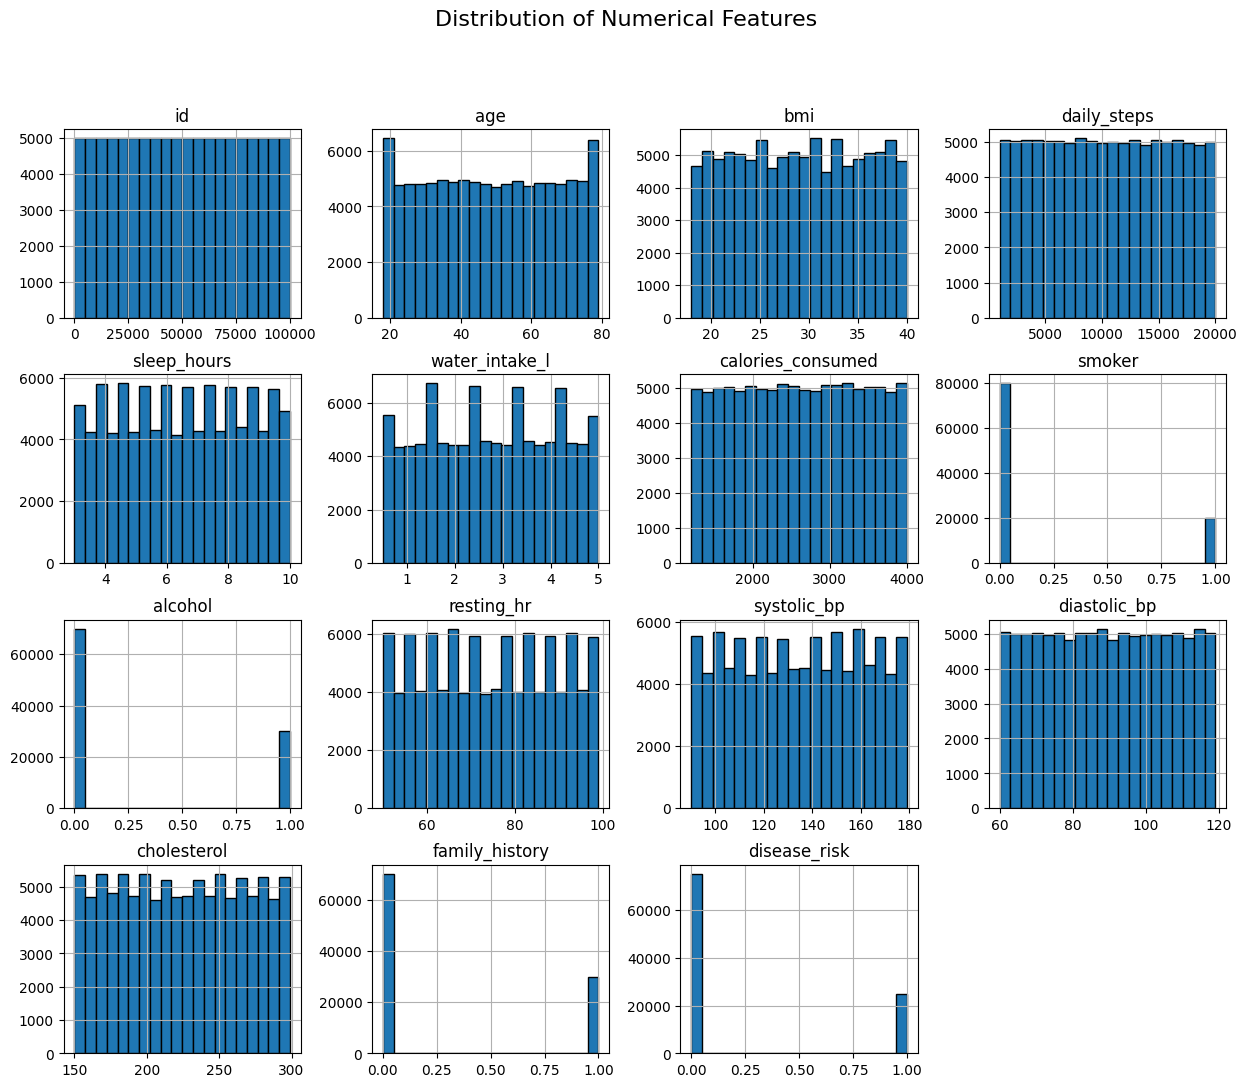

In [9]:
num_cols = data.select_dtypes(include=np.number).columns
data[num_cols].hist(bins=20, figsize=(15, 12), edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

## Numerical Feature Distribution – Summary

- Most numerical features are **evenly distributed** across their ranges.
- There are **no strong outliers or heavy skewness** in the data.
- The `id` column is **should not be used for training**.
- Binary features like `smoker`, `alcohol`, `family_history`, and `disease_risk` are **imbalanced**.
- The target variable `disease_risk` has **more 0s than 1s**, confirming class imbalance.


<Axes: xlabel='gender', ylabel='daily_steps'>

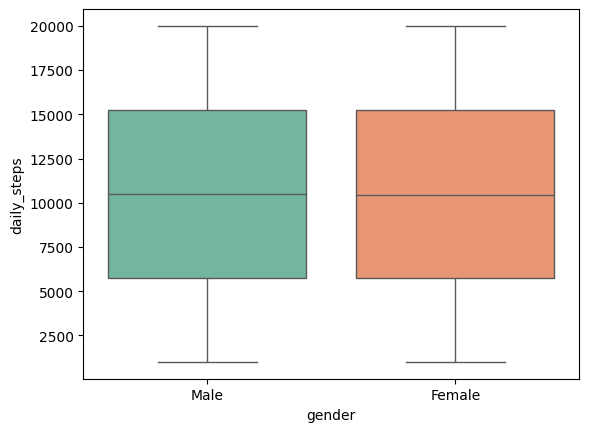

In [10]:
sns.boxplot(
    x="gender", y="daily_steps", data=data, palette="Set2", hue="gender", legend=False
)

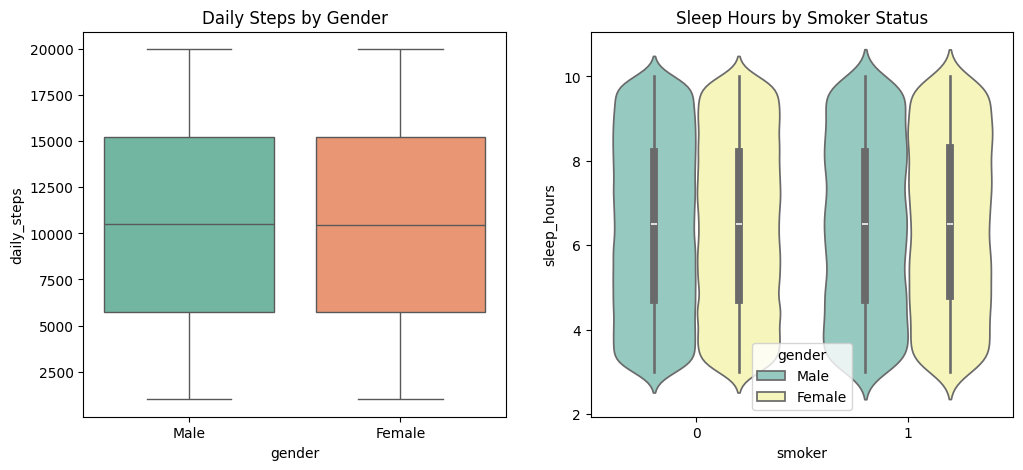

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(
    x="gender", y="daily_steps", data=data, palette="Set2", hue="gender", legend=False
)
plt.title("Daily Steps by Gender")

plt.subplot(1, 2, 2)
sns.violinplot(
    x="smoker", y="sleep_hours", data=data, palette="Set3", hue="gender", legend=True
)
plt.title("Sleep Hours by Smoker Status")
plt.show()

In [12]:
data["smoker"].value_counts()

smoker
0    79906
1    20094
Name: count, dtype: int64

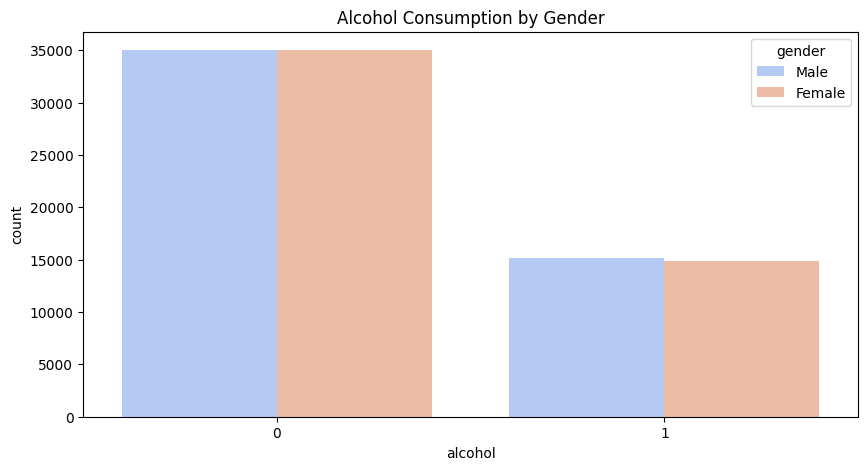

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(x="alcohol", hue="gender", data=data, palette="coolwarm")
plt.title("Alcohol Consumption by Gender")
plt.show()

In [14]:
alcohol_count = pd.crosstab(data["gender"], data["alcohol"])
alcohol_count

alcohol,0,1
gender,,
Female,35013,14855
Male,34985,15147


Text(0.5, 1.0, 'Resting Heart Rate')

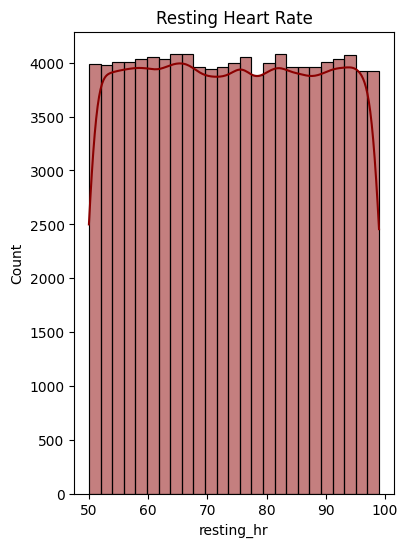

In [15]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.histplot(data["resting_hr"], bins=25, kde=True, color="darkred")
plt.title("Resting Heart Rate")

Text(0.5, 1.0, 'Blood Pressure (Systolic vs Diastolic)')

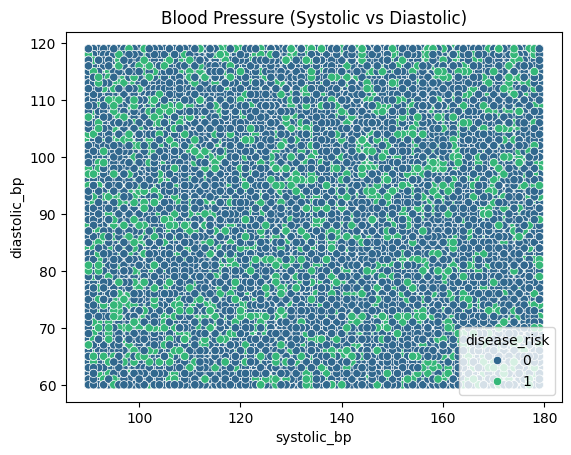

In [16]:
sns.scatterplot(
    x="systolic_bp", y="diastolic_bp", data=data, hue="disease_risk", palette="viridis"
)
plt.title("Blood Pressure (Systolic vs Diastolic)")

In [17]:
pd.crosstab(data["systolic_bp"], data["diastolic_bp"])

diastolic_bp,60,61,62,63,64,65,66,67,68,69,...,110,111,112,113,114,115,116,117,118,119
systolic_bp,,,,,,,,,,,,,,,,,,,,,
90,11,19,19,20,17,18,20,20,18,21,...,18,13,24,25,18,15,27,19,17,16
91,16,19,20,18,11,26,16,14,13,17,...,17,17,18,15,14,19,18,20,17,23
92,24,21,28,16,21,19,21,19,21,17,...,21,22,13,23,20,18,24,20,9,20
93,18,19,15,13,19,21,20,27,14,22,...,24,20,23,21,22,8,17,16,22,14
94,24,16,24,16,16,24,12,15,18,17,...,17,18,14,17,23,10,23,23,21,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,9,23,15,23,16,24,12,15,19,22,...,14,21,19,20,13,13,17,21,28,22
176,21,18,22,16,25,22,23,17,28,17,...,20,22,17,20,17,19,17,20,25,17
177,14,18,21,20,12,24,19,16,22,22,...,16,14,15,16,22,23,16,19,16,20


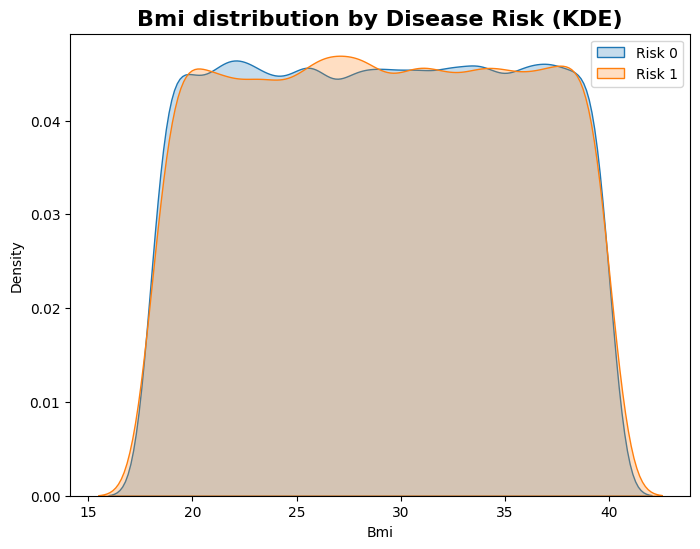

In [18]:
feature = "bmi"

figure = plt.figure(figsize=(8, 6))
sns.kdeplot(x=data.loc[data["disease_risk"] == 0, feature], label="Risk 0", fill=True)
sns.kdeplot(x=data.loc[data["disease_risk"] == 1, feature], label="Risk 1", fill=True)
plt.title(
    f"{feature.capitalize()} distribution by Disease Risk (KDE)",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel(feature.capitalize())
plt.ylabel("Density")
plt.legend()
plt.show()

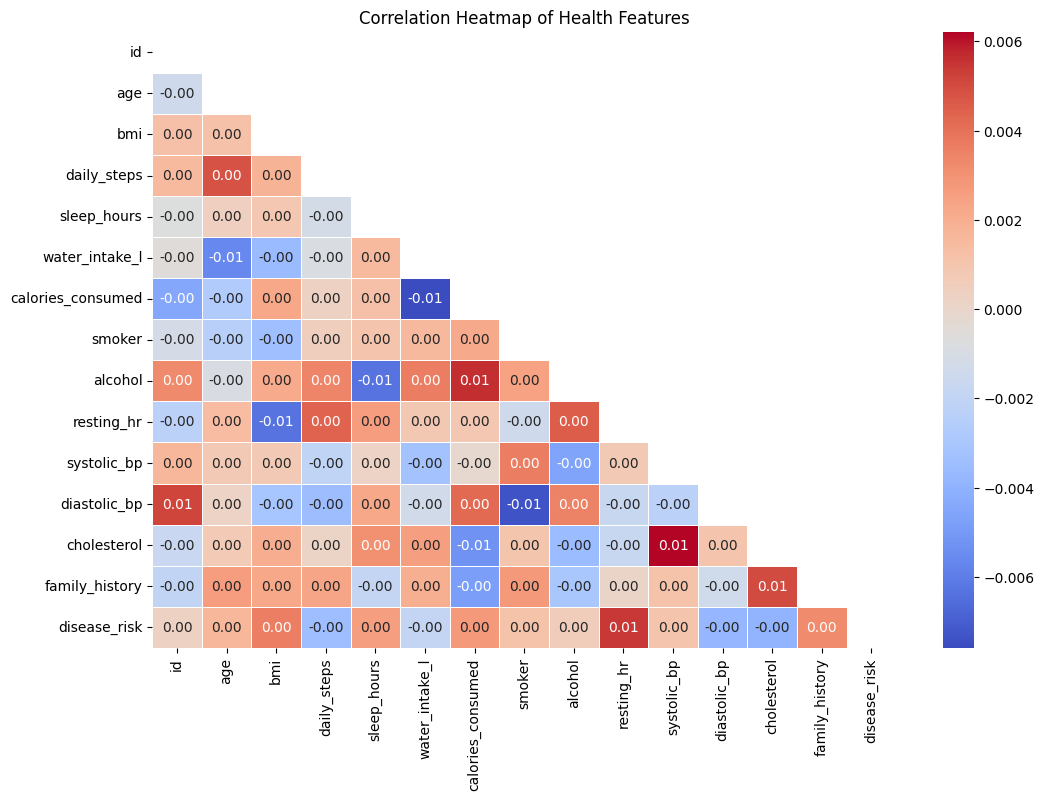

In [19]:
corr = data.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, mask=mask, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Health Features")
plt.show()

In [20]:
# corr = data.corr(numeric_only=True)
# mask = np.triu(np.ones_like(corr, dtype=bool))
# plt.figure(figsize=(12,8))
# sns.heatmap(corr, annot=True,mask=mask, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# plt.title("Correlation Heatmap of Health Features")
# plt.show()

In [21]:
mask

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False, False, False,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False, False, False, False,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, Fa

In [22]:
le = LabelEncoder()
data["gender"] = le.fit_transform(data["gender"])

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 100000 non-null  int64  
 1   age                100000 non-null  int64  
 2   gender             100000 non-null  int64  
 3   bmi                100000 non-null  float64
 4   daily_steps        100000 non-null  int64  
 5   sleep_hours        100000 non-null  float64
 6   water_intake_l     100000 non-null  float64
 7   calories_consumed  100000 non-null  int64  
 8   smoker             100000 non-null  int64  
 9   alcohol            100000 non-null  int64  
 10  resting_hr         100000 non-null  int64  
 11  systolic_bp        100000 non-null  int64  
 12  diastolic_bp       100000 non-null  int64  
 13  cholesterol        100000 non-null  int64  
 14  family_history     100000 non-null  int64  
 15  disease_risk       100000 non-null  int64  
dtypes: 

In [24]:
X = data.drop(columns=["id", "disease_risk"])
y = data["disease_risk"]

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

###   *Cross Validation to Choose Best K* 

Testing k=1... ✓ Accuracy: 0.6273 | Time elapsed: 16.6s
Testing k=2... ✓ Accuracy: 0.7223 | Time elapsed: 34.9s
Testing k=3... ✓ Accuracy: 0.6748 | Time elapsed: 53.4s
Testing k=4... ✓ Accuracy: 0.7268 | Time elapsed: 75.8s
Testing k=5... ✓ Accuracy: 0.7003 | Time elapsed: 100.1s
Testing k=6... ✓ Accuracy: 0.7333 | Time elapsed: 127.0s
Testing k=7... ✓ Accuracy: 0.7170 | Time elapsed: 158.5s
Testing k=8... ✓ Accuracy: 0.7389 | Time elapsed: 189.6s
Testing k=9... ✓ Accuracy: 0.7286 | Time elapsed: 222.8s
Testing k=10... ✓ Accuracy: 0.7422 | Time elapsed: 256.7s
Testing k=11... ✓ Accuracy: 0.7360 | Time elapsed: 293.5s
Testing k=12... ✓ Accuracy: 0.7450 | Time elapsed: 332.1s
Testing k=13... ✓ Accuracy: 0.7403 | Time elapsed: 370.5s
Testing k=14... ✓ Accuracy: 0.7465 | Time elapsed: 408.9s
Testing k=15... ✓ Accuracy: 0.7437 | Time elapsed: 448.3s
Testing k=16... ✓ Accuracy: 0.7485 | Time elapsed: 490.7s
Testing k=17... ✓ Accuracy: 0.7460 | Time elapsed: 532.1s
Testing k=18... ✓ Accuracy:

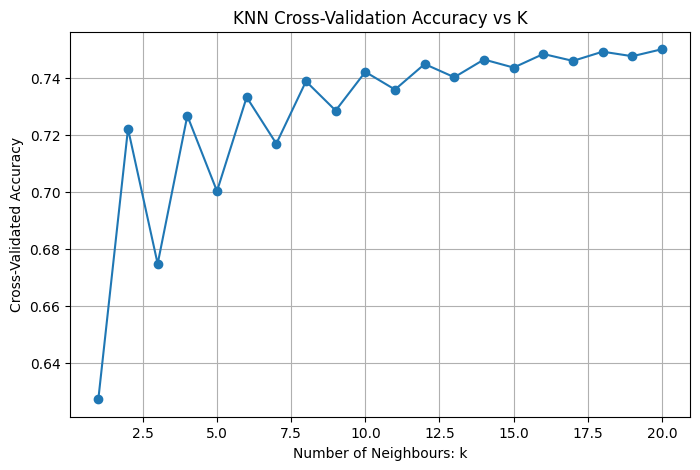

Total time taken: 666.43 seconds (11.11 minutes)


In [29]:
from time import perf_counter

start = perf_counter()

# ranges to try
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    # Print progress BEFORE running
    print(f"Testing k={k}...", end=" ", flush=True)

    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring="accuracy", n_jobs=-1)
    cv_scores.append(scores.mean())

    # Print result AFTER completing
    elapsed = perf_counter() - start
    print(f"✓ Accuracy: {scores.mean():.4f} | Time elapsed: {elapsed:.1f}s")

print("\n" + "=" * 80)
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker="o")
plt.title("KNN Cross-Validation Accuracy vs K")
plt.xlabel("Number of Neighbours: k")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()

end = perf_counter()
print(f"Total time taken: {end-start:.2f} seconds ({(end-start)/60:.2f} minutes)")

###   *Elbow Method to Choose Best K* 

Testing k=1... Accuracy: 0.6250 | Error: 0.3750 | Time: 2.8s
Testing k=2... Accuracy: 0.7203 | Error: 0.2797 | Time: 6.4s
Testing k=3... Accuracy: 0.6705 | Error: 0.3295 | Time: 10.7s
Testing k=4... Accuracy: 0.7240 | Error: 0.2760 | Time: 14.2s
Testing k=5... Accuracy: 0.6977 | Error: 0.3023 | Time: 18.0s
Testing k=6... Accuracy: 0.7305 | Error: 0.2695 | Time: 24.0s
Testing k=7... Accuracy: 0.7135 | Error: 0.2865 | Time: 29.7s
Testing k=8... Accuracy: 0.7376 | Error: 0.2624 | Time: 36.0s
Testing k=9... Accuracy: 0.7261 | Error: 0.2739 | Time: 42.3s
Testing k=10... Accuracy: 0.7415 | Error: 0.2585 | Time: 49.1s
Testing k=11... Accuracy: 0.7345 | Error: 0.2655 | Time: 56.0s
Testing k=12... Accuracy: 0.7448 | Error: 0.2552 | Time: 63.9s
Testing k=13... Accuracy: 0.7399 | Error: 0.2601 | Time: 71.9s
Testing k=14... Accuracy: 0.7458 | Error: 0.2542 | Time: 79.7s
Testing k=15... Accuracy: 0.7429 | Error: 0.2571 | Time: 88.2s
Testing k=16... Accuracy: 0.7479 | Error: 0.2521 | Time: 94.6s
Tes

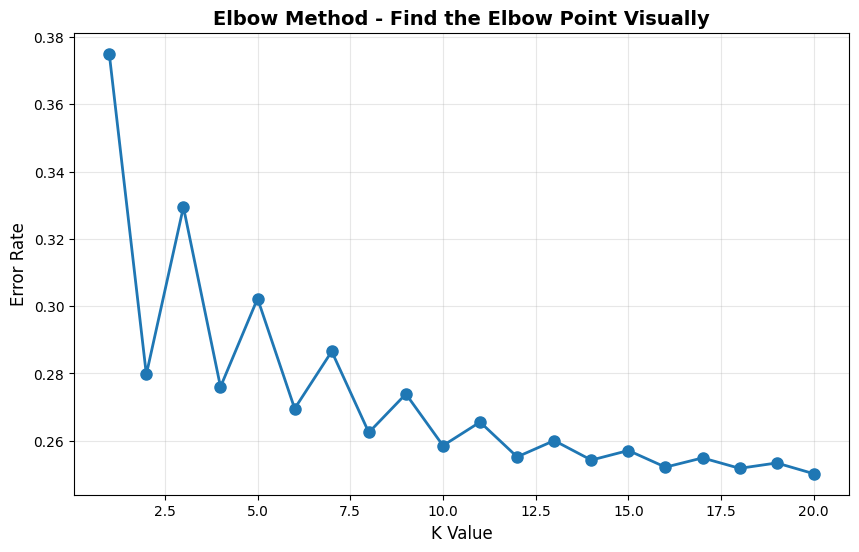


Total time: 129.1s


In [38]:
start = perf_counter()

k_values = range(1, 21)
error_rates = []

for k in k_values:
    print(f"Testing k={k}...", end=" ", flush=True)

    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    error_rate = 1 - accuracy
    error_rates.append(error_rate)

    elapsed = perf_counter() - start
    print(f"Accuracy: {accuracy:.4f} | Error: {error_rate:.4f} | Time: {elapsed:.1f}s")

plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rates, marker="o", linewidth=2, markersize=8)
plt.xlabel("K Value", fontsize=12)
plt.ylabel("Error Rate", fontsize=12)
plt.title(
    "Elbow Method - Find the Elbow Point Visually", fontsize=14, fontweight="bold"
)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nTotal time: {(perf_counter()-start):.1f}s")

In [53]:
knn_final = KNeighborsClassifier(n_neighbors=9)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:{accuracy:.4f}")
print(f"Precision:{precision:.4f}")
print(f"Recall:{recall:.4f}")
print(f"F1-Score:{f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:0.7261
Precision:0.2300
Recall:0.0441
F1-Score:0.0740

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.95      0.84     15036
           1       0.23      0.04      0.07      4964

    accuracy                           0.73     20000
   macro avg       0.49      0.50      0.46     20000
weighted avg       0.62      0.73      0.65     20000


Confusion Matrix:
[[14303   733]
 [ 4745   219]]


## Model Performance Explanation (Simple)

### 1. Accuracy: 72.61%
- The model is correct about **73 out of every 100 predictions**.
- Out of **20,000 test samples**, it correctly predicted **14,303 cases**.
- However, accuracy is misleading here because the data is imbalanced.

### 2. Precision (At-Risk): 23%
- When the model predicts **“At Risk”**, it is correct only **23% of the time**.
- Out of 100 “At Risk” predictions:
  - **23 are correct**
  - **77 are false alarms**

### 3. Recall (At-Risk): 4.41%
- The model detects only **4 out of every 100 truly at-risk people**.
- This means it **misses about 96% of at-risk cases**, which is very poor.
- Out of 100 sick people, the model identifies only **4**.

### Confusion Matrix Summary
- Many **at-risk people are wrongly classified as low risk**.
- The model is heavily biased toward predicting **Low Risk**.

### Key Takeaway
Although accuracy looks decent, the model **fails to identify at-risk individuals**, making it **unreliable for health-related use**.


## Why Is This Happening?

- The dataset is **imbalanced**:
  - **75%** of people are **Low Risk (Class 0)**
  - **25%** are **At Risk (Class 1)**

- Because most people are Low Risk, the model learns that **predicting “Low Risk” most of the time gives high accuracy**.

- The model can get about **75% accuracy by always predicting “Low Risk”**, even without really learning who is At Risk.


The KNN model has 72.61% accuracy, but it is **not good for identifying at-risk people**.  
It only detects **4% of actual at-risk cases**, even though it performs well for low-risk cases.

This happens because the dataset is **imbalanced** (75% low risk, 25% at risk).  
To improve performance, **class imbalance methods like SMOTE should be used before training**.

In [54]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Original training data: {len(X_train)}")
print(f"Balanced training data: {len(X_train_balanced)}")

# Train on balanced data
knn_smote = KNeighborsClassifier(n_neighbors=9)
knn_smote.fit(X_train_balanced, y_train_balanced)

# Evaluate on original test set
y_pred = knn_smote.predict(X_test)

# Results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Original training data: 80000
Balanced training data: 120286
Accuracy: 0.4944
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.50      0.60     15036
           1       0.24      0.49      0.33      4964

    accuracy                           0.49     20000
   macro avg       0.50      0.49      0.46     20000
weighted avg       0.62      0.49      0.53     20000

Confusion Matrix:
[[7445 7591]
 [2521 2443]]


After applying SMOTE, the model’s ability to detect at-risk people improved from **4% to 49%**, although accuracy dropped from **73% to 49%**.

This trade-off is acceptable because in healthcare, **missing sick people is more dangerous than false alarms**.  
The balanced model now identifies **nearly half of at-risk individuals**, instead of missing almost all of them.

In [55]:
X.columns

Index(['age', 'gender', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l',
       'calories_consumed', 'smoker', 'alcohol', 'resting_hr', 'systolic_bp',
       'diastolic_bp', 'cholesterol', 'family_history'],
      dtype='object')

In [56]:
X.head(2)

,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history
0,56,1,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0
1,69,0,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0


In [63]:
new_data = pd.DataFrame(
    {
        "age": [35],
        "gender": [1],
        "bmi": [25.5],
        "daily_steps": [12000],
        "sleep_hours": [8.0],
        "water_intake_l": [2.5],
        "calories_consumed": [2200],
        "smoker": [0],
        "alcohol": [0],
        "resting_hr": [65],
        "systolic_bp": [120],
        "diastolic_bp": [80],
        "cholesterol": [200],
        "family_history": [0],
    }
)

print("PATIENT PROFILE")
print(new_data.to_string(index=False))

new_data_scaled = scaler.transform(new_data)

print("\nPREDICTION RESULTS")
print(
    f"Model 1 (WITHOUT SMOTE): {['Low Risk', 'At Risk'][knn_final.predict(new_data_scaled).item()]}"
)
print(
    f"Model 2 (WITH SMOTE): {['Low Risk', 'At Risk'][knn_smote.predict(new_data_scaled).item()]}"
)

PATIENT PROFILE
 age  gender  bmi  daily_steps  sleep_hours  water_intake_l  calories_consumed  smoker  alcohol  resting_hr  systolic_bp  diastolic_bp  cholesterol  family_history
  35       1 25.5        12000          8.0             2.5               2200       0        0          65          120            80          200               0

PREDICTION RESULTS
Model 1 (WITHOUT SMOTE): At Risk
Model 2 (WITH SMOTE): At Risk


In [85]:
data.head(4)

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,1,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,0,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,1,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,0,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0


In [66]:
new_data = pd.DataFrame(
    {
        "age": [35, 50, 25, 65],
        "gender": [1, 0, 1, 0],
        "bmi": [25.5, 32.1, 21.0, 28.5],
        "daily_steps": [12000, 3000, 15000, 2000],
        "sleep_hours": [8.0, 5.0, 9.0, 4.0],
        "water_intake_l": [2.5, 1.5, 3.5, 1.0],
        "calories_consumed": [2200, 3200, 1800, 3500],
        "smoker": [0, 1, 0, 1],
        "alcohol": [0, 1, 0, 1],
        "resting_hr": [65, 85, 55, 95],
        "systolic_bp": [120, 150, 110, 160],
        "diastolic_bp": [80, 95, 70, 100],
        "cholesterol": [200, 280, 170, 300],
        "family_history": [0, 1, 0, 1],
    }
)

print("PATIENT PROFILES")
print(new_data.to_string(index=False))

new_data_scaled = scaler.transform(new_data)
pred1 = knn_final.predict(new_data_scaled)
pred2 = knn_smote.predict(new_data_scaled)

PATIENT PROFILES
 age  gender  bmi  daily_steps  sleep_hours  water_intake_l  calories_consumed  smoker  alcohol  resting_hr  systolic_bp  diastolic_bp  cholesterol  family_history
  35       1 25.5        12000          8.0             2.5               2200       0        0          65          120            80          200               0
  50       0 32.1         3000          5.0             1.5               3200       1        1          85          150            95          280               1
  25       1 21.0        15000          9.0             3.5               1800       0        0          55          110            70          170               0
  65       0 28.5         2000          4.0             1.0               3500       1        1          95          160           100          300               1


##### from training data to check 

In [ ]:
# data_dict = {
#     'age': [56, 69, 46, 32],
#     'gender': [1, 0, 1, 0],
#     'bmi': [20.5, 33.3, 31.6, 38.2],
#     'daily_steps': [4198, 14359, 1817, 15772],
#     'sleep_hours': [3.9, 9.0, 6.6, 3.6],
#     'water_intake_l': [3.4, 4.7, 4.2, 2.0],
#     'calories_consumed': [1602, 2346, 1643, 2460],
#     'smoker': [0, 0, 0, 0],
#     'alcohol': [0, 1, 1, 0],
#     'resting_hr': [97, 68, 90, 71],
#     'systolic_bp': [161, 116, 123, 165],
#     'diastolic_bp': [111, 65, 99, 95],
#     'cholesterol': [240, 207, 296, 175],
#     'family_history': [0, 0, 0, 0]
# }

# df = pd.DataFrame(data_dict)

# print("PATIENT PROFILES")
# print(df.to_string(index=False))

# data_dict_scaled = scaler.transform(df)
# pred1 = knn_final.predict(data_dict_scaled)
# pred2 = knn_smote.predict(data_dict_scaled)

# print("\nPREDICTION RESULTS")

# for i in range(len(df)):
#     status1 = 'DISEASE' if pred1[i] == 1 else 'NO DISEASE'
#     status2 = 'DISEASE' if pred2[i] == 1 else 'NO DISEASE'
#     print(f"Patient {i+1}: NO SMOTE={status1} | WITH SMOTE={status2}")

PATIENT PROFILES
 age  gender  bmi  daily_steps  sleep_hours  water_intake_l  calories_consumed  smoker  alcohol  resting_hr  systolic_bp  diastolic_bp  cholesterol  family_history
  56       1 20.5         4198          3.9             3.4               1602       0        0          97          161           111          240               0
  69       0 33.3        14359          9.0             4.7               2346       0        1          68          116            65          207               0
  46       1 31.6         1817          6.6             4.2               1643       0        1          90          123            99          296               0
  32       0 38.2        15772          3.6             2.0               2460       0        0          71          165            95          175               0

PREDICTION RESULTS
Patient 1: NO SMOTE=NO DISEASE | WITH SMOTE=NO DISEASE
Patient 2: NO SMOTE=NO DISEASE | WITH SMOTE=NO DISEASE
Patient 3: NO SMOTE=NO DISEASE | 

In [67]:
pred1

array([1, 0, 0, 0])

In [68]:
pred2

array([1, 1, 0, 1])

In [69]:
print("\nPREDICTION RESULTS")
for i in range(len(new_data)):
    result1 = "At Risk" if pred1[i] == 1 else "Low Risk"
    result2 = "At Risk" if pred2[i] == 1 else "Low Risk"
    print(f"Patient {i+1}: NO SMOTE={result1} | WITH SMOTE={result2}")


PREDICTION RESULTS
Patient 1: NO SMOTE=At Risk | WITH SMOTE=At Risk
Patient 2: NO SMOTE=Low Risk | WITH SMOTE=At Risk
Patient 3: NO SMOTE=Low Risk | WITH SMOTE=Low Risk
Patient 4: NO SMOTE=Low Risk | WITH SMOTE=At Risk


Starting Feature Importance Calculation...
Test set size: 20000 samples
Features to analyze: 14

COMPLETED in 338.13 seconds (5.64 minutes)

Top 10 Most Important Features:
       Feature  Importance
        gender   -0.001117
   cholesterol   -0.001317
water_intake_l   -0.001417
       alcohol   -0.001967
family_history   -0.002400
   daily_steps   -0.003767
        smoker   -0.003833
           bmi   -0.004017
   sleep_hours   -0.004167
    resting_hr   -0.004683


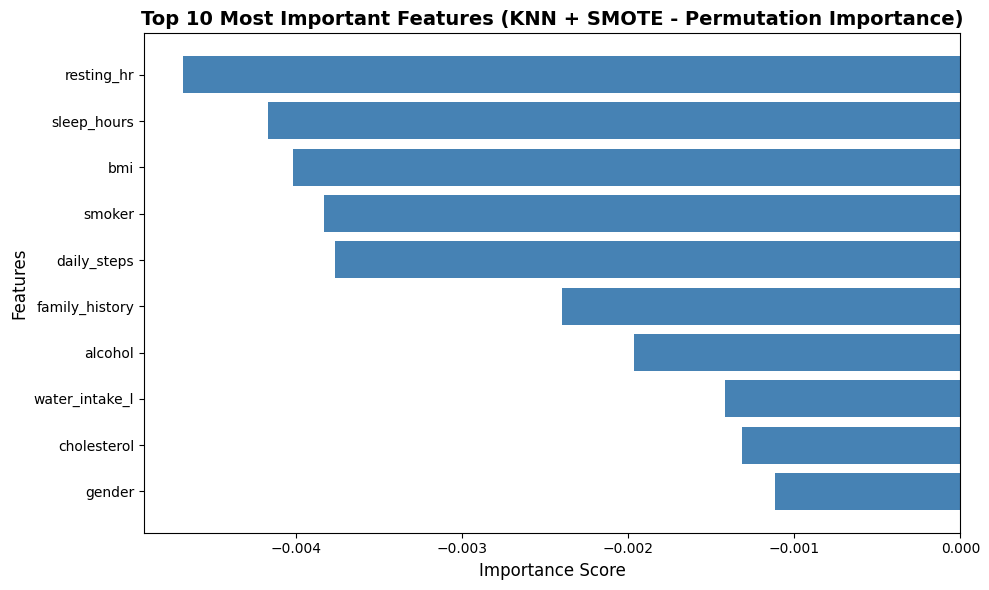

In [92]:
from sklearn.inspection import permutation_importance
import time

feature_names = [
    "age",
    "gender",
    "bmi",
    "daily_steps",
    "sleep_hours",
    "water_intake_l",
    "calories_consumed",
    "smoker",
    "alcohol",
    "resting_hr",
    "systolic_bp",
    "diastolic_bp",
    "cholesterol",
    "family_history",
]

# Start timer
start_time = time.time()
print("Starting Feature Importance Calculation...")
print(f"Test set size: {len(X_test)} samples")
print(f"Features to analyze: {len(feature_names)}")

# Calculate permutation importance
perm_importance = permutation_importance(
    knn_smote, X_test, y_test, n_repeats=3, random_state=42, n_jobs=-1
)

# Calculate elapsed time
elapsed_time = time.time() - start_time
print(f"\nCOMPLETED in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")

# Create DataFrame
feature_importance = (
    pd.DataFrame(
        {
            "Feature": feature_names,  # ← USE THIS!
            "Importance": perm_importance.importances_mean,
        }
    )
    .sort_values("Importance", ascending=False)
    .head(10)
)

# Display results
print("\nTop 10 Most Important Features:")
print(feature_importance.to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["Feature"], feature_importance["Importance"], color="steelblue"
)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title(
    "Top 10 Most Important Features (KNN + SMOTE - Permutation Importance)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### Without SMOTE 

In [94]:
# Check model accuracy first
from sklearn.metrics import accuracy_score, classification_report

y_pred = knn_final.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Check feature correlations with target
correlation = pd.DataFrame(
    {
        "Feature": feature_names,
        "Correlation": [
            np.corrcoef(X_test[:, i], y_test)[0, 1] for i in range(len(feature_names))
        ],
    }
).sort_values("Correlation", ascending=False)

print("\nFeature Correlations with Disease Risk:")
print(correlation)

Model Accuracy: 0.7261

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.95      0.84     15036
           1       0.23      0.04      0.07      4964

    accuracy                           0.73     20000
   macro avg       0.49      0.50      0.46     20000
weighted avg       0.62      0.73      0.65     20000


Feature Correlations with Disease Risk:
              Feature  Correlation
2                 bmi     0.011219
3         daily_steps     0.008422
9          resting_hr     0.006660
7              smoker     0.006274
0                 age     0.005935
4         sleep_hours     0.003407
13     family_history     0.003303
1              gender     0.000983
6   calories_consumed     0.000516
5      water_intake_l    -0.001215
11       diastolic_bp    -0.001756
8             alcohol    -0.003127
10        systolic_bp    -0.006308
12        cholesterol    -0.009367


## Findings And Issues that solved

## Methodology

- **Feature Scaling was required:**  
  KNN uses distance to make predictions. Without scaling, features like blood pressure and cholesterol dominate and give wrong results.

- **SMOTE applied after train–test split:**  
  SMOTE was used only on the training data to avoid data leakage. Using it before splitting would give misleading performance.

- **Distance sensitivity:**  
  KNN is sensitive to small changes in data. Even after scaling, slight differences can change which neighbors are selected.

### Limitations of KNN

- **Choice of K matters a lot:**  
  When K was small, the model made unstable decisions.  
  When K was large, it favored the majority (low-risk) group too much.

- **Too many features:**  
  With many input features, it became harder for the model to clearly tell people apart.

- **Slow for large data:**  
  KNN was quick to train, but slow when making predictions because it had to compare with all past data.

- **Accuracy was misleading:**  
  Models with high accuracy still failed to find at-risk people.  
  This showed that **recall and F1-score are more important than accuracy** in healthcare.


## Issues Faced and Solutions

- **Issue: Model predicted most people as Low Risk**  
  **Cause:** Data imbalance (more Low Risk cases).  
  **Solution:** Used SMOTE on training data to balance the classes.

- **Issue: Poor results before scaling**  
  **Cause:** Large-value features affected distance calculations.  
  **Solution:** Scaled all numerical features before training.

- **Issue: Risk of data leakage**  
  **Cause:** Preprocessing applied to the full dataset.  
  **Solution:** Followed the correct order: split → scale → SMOTE → train.

- **Issue: Non-useful features included**  
  **Cause:** `id` had no predictive value.  
  **Solution:** Removed `id` before training.


## KNN Disease Risk Prediction – Simple Summary

### Overview
A KNN model was used to predict disease risk.  
It achieved **72.61% accuracy**, but it is **not good at finding sick people**.

### Model Performance
- Accuracy: **72.61%**
- Disease Detection (Recall): **4%**
- This means the model **misses most at-risk patients**
- It works well only for identifying **healthy people**

Using SMOTE improved disease detection, but accuracy dropped to **49%**.

### Main Problem
- All features have **very weak relationships** with disease risk.
- Because of this, the model mostly predicts **“No Disease.”**

### Conclusion
The KNN model looks accurate, but it **fails at disease detection**.  
It is **not suitable for medical screening**
